# Lab №2
## Course "Robot Perception"

Implement an extended Kalman filter (linearized).

Task: find the position in 1D space, but unlike the previous example (where we measured the change in position according to GPS data), we use data from the camera, measuring the height of distant landmarks relative to the horizon.<br />
Important!

1.) Keep the same linear motion model as in the original
example, and assume that we know the height of the landmark and its position in the global coordinate system.

2.) Because our sensor measures an angle, our measurement model is non-linear with position
moving object.

<img src="https://likerobotics.ru/images/task2.jpg" width="400"/>

### Initial data
An object is state defined by position and speed.
Control: the change of acceleration.<br>
State $ \mathbf{x}=\left[\begin{array}{c}
p \\
\frac{d p}{d t}=\dot{p}
\end{array}\right]
$
control input  $\quad \mathbf{u}=a=\frac{d^{2} p}{d t^{2}}$
<br />


Motion model
$$
\begin{aligned}
\mathbf{x}_{k} &=\mathbf{f}\left(\mathbf{x}_{k-1}, \mathbf{u}_{k-1}, \mathbf{w}_{k-1}\right) \\
&=\left[\begin{array}{cc}
1 & \Delta t \\
0 & 1
\end{array}\right] \mathbf{x}_{k-1}+\left[\begin{array}{c}
0 \\
\Delta t
\end{array}\right] \mathbf{u}_{k-1}+\mathbf{w}_{k-1} \\
v_{k} & \sim \mathscr{N}(0,0.01) \quad \mathbf{w}_{k} \sim \mathscr{N}\left(\mathbf{0},(0.1) \mathbf{1}_{2 \times 2}\right)
\end{aligned}
$$

Measurment model
$$
\begin{aligned}
y_{k} &=\phi_{k}=h\left(p_{k}, v_{k}\right) \\
&=\tan ^{-1}\left(\frac{S}{D-p_{k}}\right)+v_{k}
\end{aligned}
$$

Jacobian of motion model
$$
\begin{array}{l}
\mathbf{F}_{k-1}=\left.\frac{\partial \mathbf{f}}{\partial \mathbf{x}_{k-1}}\right|_{\hat{\mathbf{x}}_{k-1}, \mathbf{u}_{k-1}, \mathbf{0}}=\left[\begin{array}{cc}
1 & \Delta t \\
0 & 1
\end{array}\right] \\
\mathbf{L}_{k-1}=\left.\frac{\partial \mathbf{f}}{\partial \mathbf{w}_{k-1}}\right|_{\hat{\mathbf{x}}_{k-1, \mathbf{u}_{k-1}, \mathbf{0}}}=\mathbf{1}_{2 \times 2}
\end{array}
$$

Jacobian of measurment model
$$
\begin{array}{l}
\mathbf{H}_{k}=\left.\frac{\partial h}{\partial \mathbf{x}_{k}}\right|_{\check{x}_{k}, \mathbf{0}}=\left[\begin{array}{ll}
\frac{S}{\left(D-\check{p}_{k}\right)^{2}+S^{2}} & 0
\end{array}\right] \\
M_{k}=\left.\frac{\partial h}{\partial v_{k}}\right|_{\check{x}_{k}, \mathbf{0}}=1
\end{array}
$$

Find the position of the object at the moment
time 𝒌 + 𝟏, with ∆𝒕 = 𝟎. 𝟓 sec

$$
\begin{array}{cl}
\hat{\mathbf{x}}_{0} \sim \mathscr{N}\left(\left[\begin{array}{l}
0 \\
5
\end{array}\right],\right. & \left.\left[\begin{array}{cc}
0.01 & 0 \\
0 & 1
\end{array}\right]\right) \\
u_{0}=-2\left[\mathrm{~m} / \mathrm{s}^{2}\right] & y_{1}=\pi / 6[\mathrm{rad}] \\
S=20[\mathrm{~m}] & D=40[\mathrm{~m}]
\end{array}
$$

In [4]:
import numpy as np
from numpy.linalg import inv
import matplotlib.pyplot as plt

Note: We linearize the motion model with respect to the previous estimate, and we linearize the measurement model with respect to the predicted state.

In [21]:
x_0 = np.array([[0],[5]]) #Initial state
P_0 = np.array([[0.01 , 0],
                [0, 1]]) #Initial Uncertainity (covariance at time 0)
w_k = np.array([[0.1 , 0],
                [0, 0.1]]) #Noise - motion model covariance at time 0 (Q matrix in formulas)

# measurement noise - Note: made this a 2D array for proper matrix multiplication
v_k = np.array([0.01]).reshape((1,1)) #measurement model covariance at time 0 (in R formulas)

u_0 = -2 #Control Input (acceleration)
y_1 = np.pi/6 #First Measurement
S = 20
D = 40
dt = 0.5

We now need to get predictions for x_k and P_k

In [84]:
f_matrix = np.array([[1, dt], [0, 1]]) #State transition matrix
g_matrix = np.array([[0], [dt]]) #Control Influence
x_k = f_matrix.dot(x_0) + g_matrix*u_0 #Predicted State

# propogate covariance
P_k = f_matrix@P_0@f_matrix.T + w_k #Predicted Covariance
P_k

array([[0.36, 0.5 ],
       [0.5 , 1.1 ]])

The measurement model is already different!!!
<b>Do it yourself!</b>


In [90]:
# now we need to make a correction
M_k = np.array([[1]])

p_k = x_k[0, 0]

# Calculate H_k using the given formula
H_k = np.array([[S/((D - p_k)**2 + S**2), 0]]) # Jacobian of measurement model

# Calculate the Kalman gain
K_k = (P_k @ H_k.T) @ inv(H_k @ P_k @ H_k.T + M_k @ v_k @ M_k.T)

np.set_printoptions(precision=2, suppress=True)

print("Kalman gain K_k:")
print(K_k)

Kalman gain K_k:
[[0.4 ]
 [0.55]]


In [103]:
# it remains to calculate the state

x_k = np.array([[2.5], #Predicted state before correction
 [4]])

p_k = x_k[0, 0]

h_1 = np.arctan(S/(D - p_k))

x_state = x_k + (K_k * (y_1 - h_1)) #corrected state using measurement
x_state

array([[2.51],
       [4.02]])

In [105]:
h_1

np.float64(0.4899573262537283)

In [106]:
P_state = (np.array([[1, 0],
       [0, 1]]) - K_k@H_k)@P_k
P_state

array([[0.36, 0.5 ],
       [0.5 , 1.1 ]])

## Optional part of task (not mandatory)

In [12]:
# Here it is proposed to implement for a time interval, and not just for one step, i.e. sampling is the same

In [13]:
# motion model to be used
def motion_iterate(dt, x_k, u_k, P_k):
    """
    example inputs:
    dt = 0.1
    x_k = 0
    u_k = -2
    """
    dt = 0.1
    x_k = 0
    u_k = -2
    P_k = np.array([[0.36, 0.5],
                    [0.5, 1.1]])

    w_k = np.array([[0.1 , 0],
                [0, 0.1]])



    # motion model
    f_matrix = np.array([[1, dt], [0, 1]])
    g_matrix = np.array([[0], [dt]])
    x_k = f_matrix.dot(x_k) + g_matrix*u_k

    # propogate covariance
    P_k = f_matrix@P_k@f_matrix.T + w_k

    return x_k, P_k

In [14]:
# measurments for sensor emulation

y_k = np.array([0.46364761, 0.46394331, 0.45583792, 0.4602238 , 0.46756375,
       0.4591102 , 0.47721062, 0.46612852, 0.4686494 , 0.46785832,
       0.47167686, 0.47346588, 0.46724847, 0.46946143, 0.48393537,
       0.49785568, 0.49436255, 0.47591332, 0.49836541, 0.47975576,
       0.46921458, 0.49445381, 0.49922302, 0.49645678, 0.49357358,
       0.501212  , 0.49515677, 0.50119725, 0.48464343, 0.50344966,
       0.49899733, 0.51208231, 0.50237515, 0.49932464, 0.49032495,
       0.50360651, 0.50900636, 0.49826695, 0.51304355, 0.51059352,
       0.49593827, 0.49665214, 0.49291056, 0.50055505, 0.48112357,
       0.47786448, 0.4851439 , 0.49323178, 0.47000781, 0.49015249,
       0.46713393, 0.46538848, 0.47627175, 0.48876572, 0.46216271,
       0.464675  , 0.46566391, 0.48231029, 0.46755605, 0.45045919,
       0.44866864, 0.45022331, 0.45520167, 0.46130849, 0.46091407,
       0.46192362, 0.45670061, 0.47510626, 0.47992042, 0.46464416,
       0.44155747, 0.46904419, 0.46424043, 0.46034005, 0.49771157,
       0.48968221, 0.47741036, 0.47852992, 0.47960862, 0.504725  ,
       0.48697798, 0.49645626, 0.49051927, 0.49385507, 0.47679961,
       0.48337983, 0.47792191, 0.49634281, 0.49064312, 0.49576065,
       0.48777255, 0.49498115, 0.50050901, 0.50120332, 0.49648318,
       0.5074984 , 0.51781   , 0.50036942, 0.52283242, 0.51999238,
       0.48467598, 0.50661311, 0.4945695 , 0.50373067, 0.52297719,
       0.49907473, 0.48514468, 0.48860006, 0.48219729, 0.48734352,
       0.50785521, 0.47830531, 0.46575892, 0.48477269, 0.47698408,
       0.48187168, 0.46530466, 0.47216747, 0.46088462, 0.46716672,
       0.47205074, 0.44519855, 0.45810714, 0.45256183, 0.44939034,
       0.46813864, 0.44761071, 0.46615725, 0.47755918, 0.45936484,
       0.46908277, 0.4647162 , 0.45980925, 0.47726808, 0.47526772,
       0.47133883, 0.45591039, 0.4717358 , 0.47087716, 0.47826038,
       0.48405034, 0.47820262, 0.48060574, 0.48912961, 0.47795688,
       0.50044905, 0.49672829, 0.47546591, 0.51457344, 0.50430181,
       0.50157352, 0.4943448 , 0.48872947, 0.48489598, 0.51833268,
       0.49476484, 0.49198603, 0.50433654, 0.5131182 , 0.52556212,
       0.49725721, 0.51751351, 0.48324941, 0.51120503, 0.49552137,
       0.49530067, 0.50065846, 0.48592232, 0.49253784, 0.49830319,
       0.4982004 , 0.49167788, 0.48487954, 0.49273569, 0.49923772,
       0.48737133, 0.50204233, 0.49061747, 0.47343416, 0.47757172,
       0.48589561, 0.45552238, 0.47729664, 0.45981954, 0.47062769,
       0.4707351 , 0.45901407, 0.45430863, 0.44726424, 0.47282602,
       0.48452456, 0.46796024, 0.45991716, 0.46792978, 0.4592391 ,
       0.48387024, 0.48451465, 0.47175257, 0.45830816, 0.47226228])
y_k

array([0.46364761, 0.46394331, 0.45583792, 0.4602238 , 0.46756375,
       0.4591102 , 0.47721062, 0.46612852, 0.4686494 , 0.46785832,
       0.47167686, 0.47346588, 0.46724847, 0.46946143, 0.48393537,
       0.49785568, 0.49436255, 0.47591332, 0.49836541, 0.47975576,
       0.46921458, 0.49445381, 0.49922302, 0.49645678, 0.49357358,
       0.501212  , 0.49515677, 0.50119725, 0.48464343, 0.50344966,
       0.49899733, 0.51208231, 0.50237515, 0.49932464, 0.49032495,
       0.50360651, 0.50900636, 0.49826695, 0.51304355, 0.51059352,
       0.49593827, 0.49665214, 0.49291056, 0.50055505, 0.48112357,
       0.47786448, 0.4851439 , 0.49323178, 0.47000781, 0.49015249,
       0.46713393, 0.46538848, 0.47627175, 0.48876572, 0.46216271,
       0.464675  , 0.46566391, 0.48231029, 0.46755605, 0.45045919,
       0.44866864, 0.45022331, 0.45520167, 0.46130849, 0.46091407,
       0.46192362, 0.45670061, 0.47510626, 0.47992042, 0.46464416,
       0.44155747, 0.46904419, 0.46424043, 0.46034005, 0.49771

In [15]:
# here time interval from 1 to 10 seconds
dt = 0.1 # time discretization
t_time = np.arange(0, 20.0, dt)
N = t_time.shape[0]
u_k = np.cos(t_time) * 2

x_k_check = np.zeros((N,2,1))
P_k_check = np.zeros((N,2,2))

x_k_hat = np.zeros((N,2,1))
P_k_hat = np.zeros((N,2,2))

x_k_hat[0] = np.array([[0],[5]])
P_k_hat[0] = np.array([[0.5 , 0],
                [0, 10]])


# setup motion modelling
for i in range(1,N):
    print('iteration number ', i, 'curent time ', 0.1*i)
        #...

iteration number  1 curent time  0.1
iteration number  2 curent time  0.2
iteration number  3 curent time  0.30000000000000004
iteration number  4 curent time  0.4
iteration number  5 curent time  0.5
iteration number  6 curent time  0.6000000000000001
iteration number  7 curent time  0.7000000000000001
iteration number  8 curent time  0.8
iteration number  9 curent time  0.9
iteration number  10 curent time  1.0
iteration number  11 curent time  1.1
iteration number  12 curent time  1.2000000000000002
iteration number  13 curent time  1.3
iteration number  14 curent time  1.4000000000000001
iteration number  15 curent time  1.5
iteration number  16 curent time  1.6
iteration number  17 curent time  1.7000000000000002
iteration number  18 curent time  1.8
iteration number  19 curent time  1.9000000000000001
iteration number  20 curent time  2.0
iteration number  21 curent time  2.1
iteration number  22 curent time  2.2
iteration number  23 curent time  2.3000000000000003
iteration numb

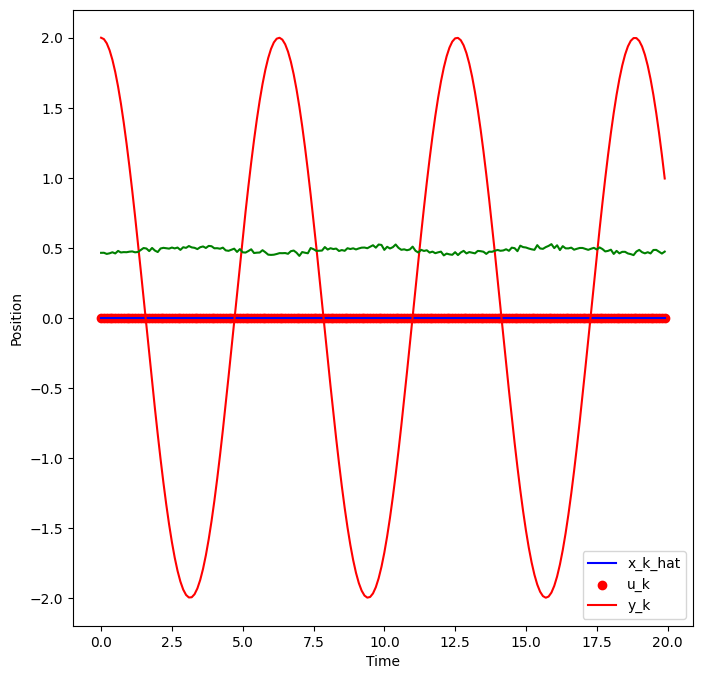

In [16]:
# visualization is power of engineers!!!!

plt.figure(figsize=(8, 8))
plt.plot(t_time[:],x_k_hat[:,0], color='b')
plt.scatter(t_time[:],x_k_check[:,0], color='r') # оценка
plt.plot(t_time[:],u_k, color='r')
plt.plot(t_time[:],y_k[:], color='g')
plt.xlabel('Time')
plt.ylabel('Position')
plt.legend(['x_k_hat', 'u_k', 'y_k'])
plt.show()

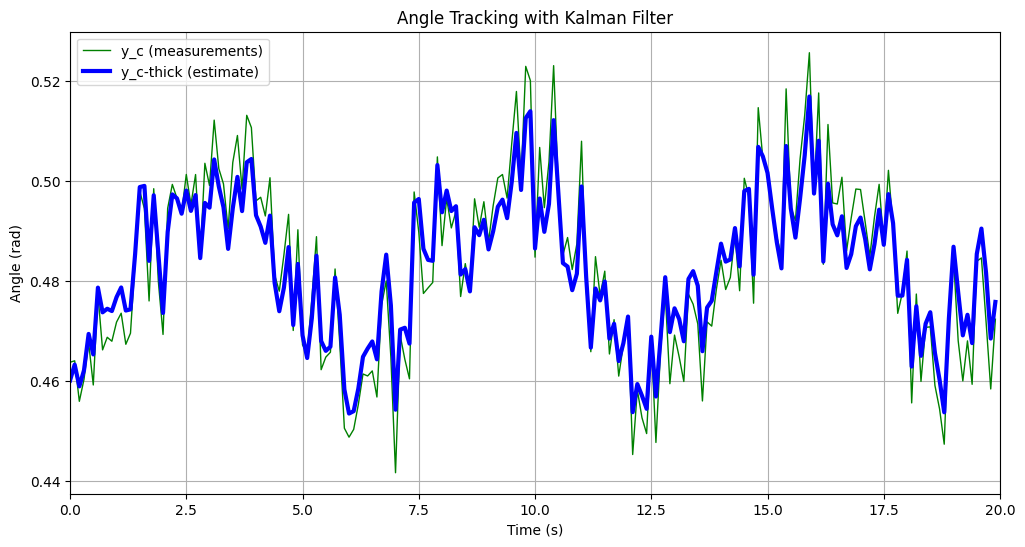

In [17]:
# Motion model for angle tracking
def motion_iterate(dt, x_k, u_k, P_k):
    # Process noise covariance (tuned for angle tracking)
    w_k = np.array([[0.01, 0],   # Reduced position noise
                    [0, 0.05]])  # Reduced velocity noise

    # Motion model matrices (constant velocity model)
    f_matrix = np.array([[1, dt],
                         [0, 1]])
    g_matrix = np.array([[0],
                         [dt]])

    # State prediction (angular position and angular velocity)
    x_k = f_matrix.dot(x_k) + g_matrix * u_k

    # Covariance propagation
    P_k = f_matrix @ P_k @ f_matrix.T + w_k

    return x_k, P_k

# Measurement update for angle tracking
def measurement_update(x_k_hat, P_k_hat, y_k, R_k):
    # Measurement matrix (we only measure angle)
    H = np.array([[1, 0]])

    # Measurement residual (handle angle wrapping if needed)
    y_residual = y_k - H @ x_k_hat

    # Residual covariance
    S = H @ P_k_hat @ H.T + R_k

    # Kalman gain
    K = P_k_hat @ H.T / S

    # State update
    x_k_hat = x_k_hat + K * y_residual

    # Covariance update
    P_k_hat = (np.eye(2) - K @ H) @ P_k_hat

    return x_k_hat, P_k_hat

# Parameters
dt = 0.1  # time discretization
t_time = np.arange(0, 20.0, dt)
N = t_time.shape[0]
u_k = np.cos(t_time) * 0.5  # Reduced control input for smoother motion

# Measurement noise covariance (tuned for angle measurements)
R_k = 0.005  # Reduced measurement noise

# Initialization
x_k_hat = np.zeros((N, 2, 1))
P_k_hat = np.zeros((N, 2, 2))

# Initial state: [angle, angular velocity]
x_k_hat[0] = np.array([[0.46], [0]])  # Starting near first measurement
P_k_hat[0] = np.array([[0.01, 0],
                       [0, 0.1]])  # Tighter initial covariance

# Kalman filter loop
for i in range(1, N):
    # Prediction step
    x_k_hat[i], P_k_hat[i] = motion_iterate(dt, x_k_hat[i-1], u_k[i-1], P_k_hat[i-1])

    # Measurement update step (only when measurement available)
    if i < len(y_k):
        x_k_hat[i], P_k_hat[i] = measurement_update(x_k_hat[i], P_k_hat[i], y_k[i], R_k)

# Visualization matching the reference plot
plt.figure(figsize=(12, 6))
plt.plot(t_time[:len(y_k)], y_k, 'g-', linewidth=1, label='y_c (measurements)')
plt.plot(t_time, x_k_hat[:, 0], 'b-', linewidth=3, label='y_c-thick (estimate)')
plt.xlabel('Time (s)')
plt.ylabel('Angle (rad)')
plt.title('Angle Tracking with Kalman Filter')
plt.legend()
plt.grid(True)

# Set x-axis ticks to match reference image
plt.xticks(np.arange(0, 20.1, 2.5))
plt.xlim(0, 20)

plt.show()